# Music Support Bot Notebook

## Setup

In [54]:
from dotenv import load_dotenv

# Load environment variables from .env
load_dotenv()

True

In [55]:
import operator
import sqlite3
import textwrap
from enum import Enum
from typing import Annotated, Literal

import requests
from IPython.display import Image, display
from langchain_community.utilities.sql_database import SQLDatabase
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from pydantic import BaseModel, Field
from sqlalchemy import create_engine
from sqlalchemy.pool import StaticPool

## Setup tools

In [56]:
# Database setup
def get_engine_for_chinook_db():
    """Pull sql file, populate in-memory database, and create engine."""
    url = "https://raw.githubusercontent.com/lerocha/chinook-database/master/ChinookDatabase/DataSources/Chinook_Sqlite.sql"
    response = requests.get(url)
    sql_script = response.text

    connection = sqlite3.connect(":memory:", check_same_thread=False)
    connection.executescript(sql_script)
    return create_engine(
        "sqlite://",
        creator=lambda: connection,
        poolclass=StaticPool,
        connect_args={"check_same_thread": False},
    )


engine = get_engine_for_chinook_db()
db = SQLDatabase(engine)


@tool
def recommend_songs_by_genre(genre: str):
    """Recommend songs by genre."""
    print(f"recommend_songs_by_genre: {genre}")
    return db.run(
        f"""
        SELECT Track.Name as SongName, Genre.Name as GenreName
        FROM Track
        LEFT JOIN Genre ON Track.GenreId = Genre.GenreId
        WHERE Genre.Name LIKE '%{genre}%';
        """,
        include_columns=True,
    )


@tool
def get_albums_by_artist(artist: str):
    """Get albums by an artist."""
    print(f"get_albums_by_artist: {artist}")
    return db.run(
        f"""
        SELECT * FROM public.artist
        ORDER BY artist_id ASC 
        """,
        include_columns=True,
    )


@tool
def get_tracks_by_artist(artist: str):
    """Get songs by an artist (or similar artists)."""
    print(f"get_tracks_by_artist: {artist}")
    return db.run(
        f"""
        SELECT Track.Name as SongName, Artist.Name as ArtistName
        FROM Album
        LEFT JOIN Artist ON Album.ArtistId = Artist.ArtistId
        LEFT JOIN Track ON Track.AlbumId = Album.AlbumId
        WHERE Artist.Name LIKE '%{artist}%';
        """,
        include_columns=True,
    )


@tool
def check_for_songs(song_title: str):
    """Check if a song exists by its name."""
    print(f"check_for_songs: {song_title}")
    return db.run(
        f"""
        SELECT * FROM Track WHERE Name LIKE '%{song_title}%';
        """,
        include_columns=True,
    )


# TODO: can use playlist to find similar tracks

In [57]:
print(db.get_usable_table_names())

['Album', 'Artist', 'Customer', 'Employee', 'Genre', 'Invoice', 'InvoiceLine', 'MediaType', 'Playlist', 'PlaylistTrack', 'Track']


In [58]:
print(db.run("SELECT * FROM Genre;", include_columns=True))

[{'GenreId': 1, 'Name': 'Rock'}, {'GenreId': 2, 'Name': 'Jazz'}, {'GenreId': 3, 'Name': 'Metal'}, {'GenreId': 4, 'Name': 'Alternative & Punk'}, {'GenreId': 5, 'Name': 'Rock And Roll'}, {'GenreId': 6, 'Name': 'Blues'}, {'GenreId': 7, 'Name': 'Latin'}, {'GenreId': 8, 'Name': 'Reggae'}, {'GenreId': 9, 'Name': 'Pop'}, {'GenreId': 10, 'Name': 'Soundtrack'}, {'GenreId': 11, 'Name': 'Bossa Nova'}, {'GenreId': 12, 'Name': 'Easy Listening'}, {'GenreId': 13, 'Name': 'Heavy Metal'}, {'GenreId': 14, 'Name': 'R&B/Soul'}, {'GenreId': 15, 'Name': 'Electronica/Dance'}, {'GenreId': 16, 'Name': 'World'}, {'GenreId': 17, 'Name': 'Hip Hop/Rap'}, {'GenreId': 18, 'Name': 'Science Fiction'}, {'GenreId': 19, 'Name': 'TV Shows'}, {'GenreId': 20, 'Name': 'Sci Fi & Fantasy'}, {'GenreId': 21, 'Name': 'Drama'}, {'GenreId': 22, 'Name': 'Comedy'}, {'GenreId': 23, 'Name': 'Alternative'}, {'GenreId': 24, 'Name': 'Classical'}, {'GenreId': 25, 'Name': 'Opera'}]


In [59]:
class GenreEnum(str, Enum):
    ROCK = ("Rock", 1)
    JAZZ = ("Jazz", 2)
    METAL = ("Metal", 3)
    ALTERNATIVE_PUNK = ("Alternative & Punk", 4)
    ROCK_AND_ROLL = ("Rock And Roll", 5)
    BLUES = ("Blues", 6)
    LATIN = ("Latin", 7)
    REGGAE = ("Reggae", 8)
    POP = ("Pop", 9)
    SOUNDTRACK = ("Soundtrack", 10)
    BOSSA_NOVA = ("Bossa Nova", 11)
    EASY_LISTENING = ("Easy Listening", 12)
    HEAVY_METAL = ("Heavy Metal", 13)
    RB_SOUL = ("R&B/Soul", 14)
    ELECTRONICA_DANCE = ("Electronica/Dance", 15)
    WORLD = ("World", 16)
    HIP_HOP_RAP = ("Hip Hop/Rap", 17)
    SCIENCE_FICTION = ("Science Fiction", 18)
    TV_SHOWS = ("TV Shows", 19)
    SCI_FI_FANTASY = ("Sci Fi & Fantasy", 20)
    DRAMA = ("Drama", 21)
    COMEDY = ("Comedy", 22)
    ALTERNATIVE = ("Alternative", 23)
    CLASSICAL = ("Classical", 24)
    OPERA = ("Opera", 25)

    def __new__(cls, name, genre_id):
        obj = str.__new__(cls, name)
        obj._value_ = name
        obj.genre_id = genre_id
        return obj


## Define state schema

In [61]:
class MusicRecommendationQuery(BaseModel):
    intent: Literal["similar_song", "similar_artist", "similar_album", "genre_recommendation"]

class MusicQuery(BaseModel):
    artist: str | None = Field(default=None, description="The name of the artist")
    album: str | None = Field(default=None, description="The name of the album")
    song: str | None = Field(default=None, description="The name of the song")


class MessageClassification(BaseModel):
    intent: Literal["music_query", "customer_support", "other"]
    # urgency: Literal["low", "medium", "high", "critical"]
    # topic: str
    # summary: str

class MessageAgentState(BaseModel):
    # Raw message data
    message_content: str
    message_id: int
    sender_number: str

    # Classification result
    message_classification: MessageClassification | None = None

    # Music query
    music_recommendation_query: MusicRecommendationQuery | None = None
    music_query: MusicQuery | None = None
    search_results: Annotated[list[str], operator.add] = Field(default_factory=list)

    # # Generated content
    # draft_response: str | None

## Define Nodes

In [62]:
# Setup LLM
reasoning = {
    "effort": "low",  # 'low', 'medium', or 'high'
    "summary": None,  # 'detailed', 'auto', or None
}

llm = ChatOpenAI(model="gpt-5-nano", reasoning=reasoning)

In [63]:
# -----------------------------------------------------------------------------
# Classify intent
# -----------------------------------------------------------------------------

def classify_intent(state: MessageAgentState) -> MessageAgentState:
    """Use LLM to classify email intent and urgency, then route accordingly"""

    # Create structured LLM that returns MessageClassification
    structured_llm = llm.with_structured_output(MessageClassification)

    classification_prompt = textwrap.dedent(f"""
    Analyze this customer message and classify it:

    Message: {state.message_content}
    From: {state.sender_number}

    Provide a classification:
    - intent: either "music_query
    " or "customer_support" or "other"

    music_query: user is asking about music, artists, albums, or playlists
    customer_support: user is asking for help with their account, billing, or technical issues
    other: if the message doesn't fit either category or is too vague to classify
    """)

    # Get structured output from LLM
    message_classification = structured_llm.invoke(classification_prompt)
    state.message_classification = message_classification

    return state


def route_after_classification(
    state: MessageAgentState,
) -> Literal["customer_support_query", "parse_music_query", "__end__"]:
    if state.message_classification and state.message_classification.intent == "customer_support":
        return "customer_support_query"
    if state.message_classification and state.message_classification.intent == "music_query":
        return "parse_music_query"
    return END


# -----------------------------------------------------------------------------
# Parse music query
# -----------------------------------------------------------------------------


def classify_recommendation_query(state: MessageAgentState) -> MessageAgentState:
    """Use an LLM to identify what the music query goal is"""
    CLASSIFY_MUSIC_QUERY_PROMPT = """
        You are an intent classification assistant for a music recommendation system.
        Your job is to determine what the user is asking for.

        Classify the query into one of these intents:

        1. similar_song
        - The user wants songs similar to a specific song or track
        - Examples:
            - "Give me songs like Yellow"
            - "What are tracks similar to Bohemian Rhapsody?"
            - "Recommend songs with the same vibe as this song"

        2. similar_artist
        - The user wants artists similar to a specific artist
        - Examples:
            - "Who sounds like Radiohead?"
            - "Recommend artists like Drake"
            - "What artists are similar to The Beatles?"

        3. similar_album
        - The user wants albums similar to a specific album
        - Examples:
            - "What albums are like Currents?"
            - "Recommend albums similar to Blonde"
            - "I want records with the same feel as Rumours"
     """

    structured_llm = llm.with_structured_output(MusicRecommendationQuery)
    music_recommendation_query = structured_llm.invoke(CLASSIFY_MUSIC_QUERY_PROMPT)
    state.music_recommendation_query = music_recommendation_query
    return state


def parse_music_query(state: MessageAgentState) -> dict:
    structured_llm = llm.with_structured_output(MusicQuery)

    prompt = textwrap.dedent(
        f"""
    Analyze this customer message and extract music query information.

    Message: {state.message_content}

    Extract the following information if present:
    - artist: the name of the artist mentioned in the message, or None if not mentioned
    - album: the name of the album mentioned in the message, or None if not mentioned
    - song: the name of the song mentioned in the message, or None if not mentioned
    """
    )

    music_query = structured_llm.invoke(prompt)
    return {"music_query": music_query}


# def search_album_by_artist(state: MessageAgentState) -> dict:
#     print("Searching for albums by artist:", state.music_query.artist)
#     if state.music_query and state.music_query.artist:
#         albums = get_albums_by_artist(state.music_query.artist)
#         print("Albums found:", albums)
#         return {"search_results": [f"Albums by artist:\n{albums}"]}
#     return {}


# def search_tracks_by_artist(state: MessageAgentState) -> dict:
#     print("Searching for tracks by artist:", state.music_query.artist)
#     if state.music_query and state.music_query.artist:
#         tracks = get_tracks_by_artist(state.music_query.artist)
#         print("Tracks found:", tracks)
#         return {"search_results": [f"Tracks by artist:\n{tracks}"]}
#     return {}


# def search_for_songs(state: MessageAgentState) -> dict:
#     print("Searching for songs matching:", state.music_query.song)
#     if state.music_query and state.music_query.song:
#         songs = check_for_songs(state.music_query.song)
#         print("Songs found:", songs)
#         return {"search_results": [f"Song matches:\n{songs}"]}
#     return {}


# def route_after_music_query_classification(
#     state: MessageAgentState,
# ) -> list[str] | Literal["__end__"]:
#     if not state.music_query:
#         return END

#     next_nodes: list[str] = []

#     if state.music_query.artist:
#         next_nodes.append("search_album_by_artist")
#         next_nodes.append("search_tracks_by_artist")

#     if state.music_query.song:
#         next_nodes.append("search_for_songs")

#     if not next_nodes:
#         return END

#     return next_nodes


# -----------------------------------------------------------------------------
# Customer support query
# -----------------------------------------------------------------------------

def customer_support_query(state: MessageAgentState) -> MessageAgentState:
    """Handle customer support queries based on classified intent and topic"""
    print("Handling customer support query for:", state.message_content)
    return state

## Build the graph

In [64]:
# Memory
memory = InMemorySaver()


# Build graph
builder = StateGraph(MessageAgentState)


# Add nodes
builder.add_node("classify_intent", classify_intent)
builder.add_node("customer_support_query", customer_support_query)

builder.add_node("classify_recommendation_query", classify_recommendation_query)
builder.add_node("parse_music_query", parse_music_query)

# builder.add_node("search_album_by_artist", search_album_by_artist)
# builder.add_node("search_tracks_by_artist", search_tracks_by_artist)
# builder.add_node("search_for_songs", search_for_songs)


# Add edges
builder.add_edge(START, "classify_intent")

builder.add_conditional_edges(
    "classify_intent",
    route_after_classification,
    [
        "customer_support_query",
        "parse_music_query",
        END,
    ],
)

builder.add_edge("parse_music_query", "classify_recommendation_query")
builder.add_edge("classify_recommendation_query", END)
builder.add_edge("customer_support_query", END)

# builder.add_conditional_edges(
#     "parse_music_query",
#     route_after_music_query_classification,
#     [
#         "search_album_by_artist",
#         "search_tracks_by_artist",
#         "search_for_songs",
#         END,
#     ],
# )
# builder.add_edge("search_album_by_artist", END)
# builder.add_edge("search_tracks_by_artist", END)
# builder.add_edge("search_for_songs", END)

# Build graph
graph = builder.compile(checkpointer=memory)


message_id = 0

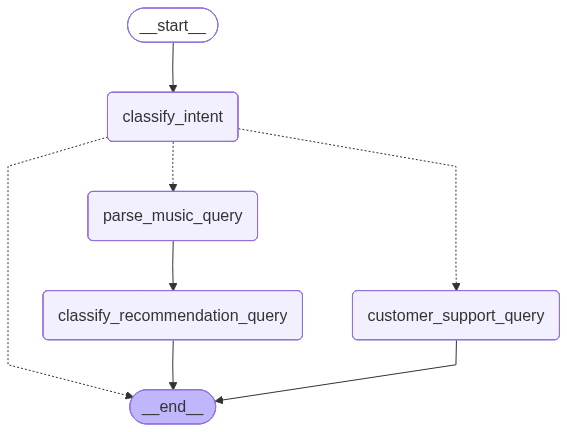

In [65]:
display(Image(graph.get_graph().draw_mermaid_png()))

## Test

In [53]:
# Simulate incoming message
message_id += 1

initial_message = MessageAgentState(
    message_content="Find me music like AC/DC",
    message_id=message_id,
    sender_number="555-123-1234",
)

config = {"configurable": {"thread_id": str(message_id)}}
result = graph.invoke(initial_message, config=config)

In [22]:
print(result)

{'message_content': 'Find me music like AC/DC', 'message_id': 2, 'sender_number': '555-123-1234', 'message_classification': MessageClassification(intent='music_query'), 'music_recommendation_query': MusicRecommendationQuery(intent='similar_song'), 'music_query': MusicQuery(artist='AC/DC', album=None, song=None), 'search_results': []}


In [ ]:
# Simulate incoming message
message_id += 1

initial_message = MessageAgentState(
    message_content="I have a billing issue with my subscription",
    message_id=message_id,
    sender_number="555-123-1234",
)

config = {"configurable": {"thread_id": str(message_id)}}
result = graph.invoke(initial_message, config=config)

Handling customer support query for: I have a billing issue with my subscription


In [187]:
# Simulate incoming message
message_id += 1

initial_message = MessageAgentState(
    message_content="How are you?",
    message_id=message_id,
    sender_number="555-123-1234",
)

config = {"configurable": {"thread_id": str(message_id)}}
result = graph.invoke(initial_message, config=config)